In [289]:
%pip install pyomo

Note: you may need to restart the kernel to use updated packages.


In [290]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import math
import pyomo.environ as pyo

### Data cleaning

In [291]:
df = pd.read_csv("ratings.csv")

df_est = df.copy()

df_est["ortg"] = (df_est["ortg"] - df_est["ortg"].mean()) / df_est["ortg"].std()
df_est["drtg"] = (df_est["drtg"] - df_est["drtg"].mean()) / df_est["drtg"].std()
df_est["netrtg"] = (df_est["netrtg"] - df_est["netrtg"].mean()) / df_est["netrtg"].std()
df_est["proj_wins"] = 2 * (df_est["proj_wins"] - df_est["proj_wins"].mean()) / df_est["proj_wins"].std()

### Modelo con victorias esperadas

In [292]:
kmeans = KMeans(n_clusters=4, random_state=0)

In [293]:
x = df_est[["netrtg","proj_wins"]]
kmeans.fit(x)

df["cluster"] = kmeans.labels_
df.to_csv("ratings_cluster.csv")
df.sort_values(by="proj_wins",ascending=False)

c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,team,ortg,drtg,netrtg,proj_wins,cluster
14,Oklahoma City Thunder,120.3000,107.5000,12.8000,62.5000,3
18,Cleveland Cavaliers,121.7000,112.2000,9.5000,56.5000,3
10,Denver Nuggets,119.9000,116.0000,3.9000,53.5000,3
1,New York Knicks,118.5000,114.3000,4.2000,53.5000,3
13,Houston Rockets,115.3000,110.8000,4.6000,52.5000,3
27,Orlando Magic,109.4000,109.6000,-0.1000,51.5000,0
24,Minnesota Timberwolves,116.6000,111.5000,5.1000,49.5000,0
17,Los Angeles Clippers,115.1000,110.3000,4.7000,49.5000,0
2,Golden State Warriors,115.0000,111.7000,3.3000,47.5000,0
6,Atlanta Hawks,114.6000,115.7000,-1.1000,47.5000,0


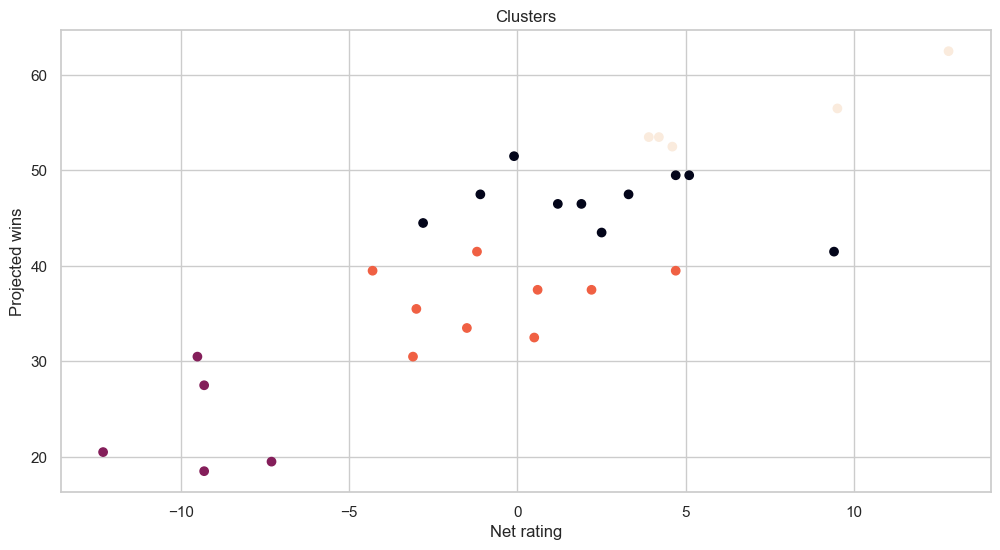

In [294]:
plt.scatter(df["netrtg"], df["proj_wins"], c=df["cluster"])
plt.xlabel("Net rating")
plt.ylabel("Projected wins")
plt.title("Clusters")
plt.show()

In [295]:
df.groupby(by="cluster")["netrtg"].mean()

cluster
0    2.4100
1   -9.5400
2   -0.5667
3    7.0000
Name: netrtg, dtype: float64

In [296]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

net_embiid = 5.4
net_not_embiid = -3.7

poss = 98.17
# Standard deviation of possessions per game
sigma = 12

# Añadir algo en casa y fuera
# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

# Differences of net ratings with clusters if Embiid plays or not
diffs_embiid = [net_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_not_embiid = [net_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_embiid]
win_not_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_not_embiid]

win_probs, win_not_probs

# Against cluster 1: 14
# Against cluster 2: 28
# Against cluster 3: 25
# Against cluster 4: 15

# Todos oeste -> 2 partidos (30)
# Todos division (Raptors, Celtics, Knicks, Nets) -> 4 partidos (16)
# Resto -> Contra 6 4 partidos, contra 4 3 partidos (36)
# Magic –> 3
# Heat –> 3
# Wizards -> 4
# Hornets -> 3
# Hawks -> 3
# Bulls -> 3 (+1)
# Bucks -> 4
# Pacers -> 3 (+1)
# Cavs -> 4
# Pistons -> 4

# Cluster nuevo
# Con Embiid -> 53 victorias en 82 partidos
# Sin Embiid -> 31 victorias en 82 partidos

([0.5966195959965248,
  0.8891871170976309,
  0.6872686593350312,
  0.44792984426918747],
 [0.3085907319380298,
  0.6835897202682024,
  0.39884694475545124,
  0.19069197482712835])

### Modelo muy basado en temporada anterior

In [297]:
kmeans_alt = KMeans(n_clusters=4, random_state=0)
x_alt = df_est[["ortg","drtg","netrtg"]]
kmeans_alt.fit(x_alt)

c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, random_state=0)

In [298]:
df_alt = df.copy()
df_alt["cluster"] = kmeans_alt.labels_
df_alt

,team,ortg,drtg,netrtg,proj_wins,cluster
0,Boston Celtics,120.6000,111.1000,9.4000,41.5000,3
1,New York Knicks,118.5000,114.3000,4.2000,53.5000,0
2,Golden State Warriors,115.0000,111.7000,3.3000,47.5000,0
3,Detroit Pistons,115.0000,113.1000,1.9000,46.5000,0
4,Los Angeles Lakers,115.9000,114.7000,1.2000,46.5000,0
5,Sacramento Kings,116.7000,116.2000,0.5000,32.5000,2
6,Atlanta Hawks,114.6000,115.7000,-1.1000,47.5000,2
7,Washington Wizards,106.8000,119.1000,-12.3000,20.5000,1
8,Chicago Bulls,114.1000,115.6000,-1.5000,33.5000,2
9,San Antonio Spurs,114.4000,117.2000,-2.8000,44.5000,2


In [299]:
df_alt.groupby(by="cluster")["netrtg"].mean()

cluster
0    2.9846
1   -9.5400
2   -2.0625
3   10.5667
Name: netrtg, dtype: float64

In [300]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

net_embiid = 5.4
net_not_embiid = -3.7

poss = 98.17
# Standard deviation of difference of points per game
# Con 12 funciona bastante bien
sigma = 12

# Suponiendo que el margen real sigue (aprox.) una distribución normal, 
# la probabilidad de ganar es la probabilidad de que el margen sea > 0

# Añadir algo en casa y fuera
# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

# Differences of net ratings with clusters if Embiid plays or not
diffs_embiid = [net_embiid - net for net in df_alt.groupby(by="cluster")["netrtg"].mean()]
diffs_not_embiid = [net_not_embiid - net for net in df_alt.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_embiid]
win_not_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_not_embiid]

win_probs, win_not_probs

# Cluster antiguo
# Con Embiid -> 51 victorias en 80 partidos
# Sin Embiid -> 30/31 victorias en 80 partidos

([0.5783204308644903,
  0.8891871170976309,
  0.7292329192536076,
  0.33626569229347963],
 [0.29223840603526946,
  0.6835897202682024,
  0.446716649286113,
  0.12157848850214237])

### Separación casa/fuera

In [301]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

net_home_embiid = 6.4
net_home_not_embiid = -3.7
net_away_embiid = 4.2
net_away_not_embiid = -3.8

poss = 98.17
# Standard deviation of difference of points per game
# Con 12 funciona bastante bien
sigma = 12

# Todos oeste -> 2 partidos (30)
# Todos division (Raptors, Celtics, Knicks, Nets) -> 4 partidos (16)
# Resto -> Contra 6 4 partidos, contra 4 3 partidos (36)
# Magic –> 3
# Heat –> 3 (+1)
# Wizards -> 4
# Hornets -> 3
# Hawks -> 3
# Bulls -> 3
# Bucks -> 4
# Pacers -> 3 (+1)
# Cavs -> 4
# Pistons -> 4

# Hay que poner como constraint que no juegue en Denver por favor
# Lleva sin jugar desde el 8 de noviembre de 2019 🤣

In [302]:
# At home: 41
# Against cluster 1: 7
# Against cluster 2: 15
# Against cluster 3: 12
# Against cluster 4: 7

# Differences of net ratings with clusters if Embiid plays or not AT HOME
diffs_home_embiid = [net_home_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_home_not_embiid = [net_home_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_home_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_home_embiid]
win_home_not_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_home_not_embiid]

win_home_embiid_probs, win_home_not_embiid_probs

# En casa con Embiid: 27/28 victorias de 41
# En casa sin Embiid: 15/16 victorias de 41

([0.6279448994938123,
  0.9038874422925967,
  0.7156378828027741,
  0.4804257786319578],
 [0.3085907319380298,
  0.6835897202682024,
  0.39884694475545124,
  0.19069197482712835])

In [303]:
# Away: 41
# Against cluster 1: 7
# Against cluster 2: 13
# Against cluster 3: 13
# Against cluster 4: 8

# Differences of net ratings with clusters if Embiid plays or not AWAY
diffs_away_embiid = [net_away_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_away_not_embiid = [net_away_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_away_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_away_embiid]
win_away_not_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_away_not_embiid]

win_away_embiid_probs, win_away_not_embiid_probs

# Fuera con Embiid: 25/26 victorias de 41
# Fuera sin Embiid: 15/16 victorias de 41

([0.5582117569389846,
  0.8695033501188123,
  0.6517143697163756,
  0.40940984578293965],
 [0.30571623988778884,
  0.6806723822265628,
  0.3956920890266532,
  0.18847499049271899])

In [304]:
# Total: 
# Con Embiid: 54/56 victorias de 82
# Sin Embiid: 30/32 victorias de 82

### Ideas de constraints

In [305]:
# Si Embiid juega menos de 24-27 minutos es como si no jugara (para eso mejor que no juegue)
# A partir de ahí regresión lineal hasta 36-37-38 minutos -> va aumentando la probabilidad según juegue más
# Embiid tiene 33.1 minutos por partido entre las temporadas 20-21 y 24-25
# Su máximo en una temporada son 34.6 en la 22-23, cuando fue MVP
# Si juega más de X minutos en un partido no puede jugar el siguiente
# En vez de no jugar el siguiente partido, podría ser que los minutos acumulados pesaran más de cara a calcular la probabilidad de lesión
# Los 76ers deben ganar un número mínimo de partidos para clasificar a playoffs (por definir, yo diria unas 50)
# Partidos de copa -> Embiid tiene que jugarlos obligatoriamente -> sanción
# Si juega menos minutos de los que le gustaría en la temporada pedirá el traspaso
# No puede jugar en Denver (jajajaja)

# MINIMIZAR minutos jugados por Embiid en la temporada
# Igual seria buena idea ignorar lo de que si no juega suficiente se enfadará y pedirá el traspaso (lo veo complicado de modelar)

# Modelado e implementación de nuestro modelo

![Model Approach](model_approach.jpg)

### Parámetros

##### Calculo de parametro $P_{gr}$ (Games x Rating/Cluster)
Extraemos los datos del calendario y cruzamos con los clusters calculados para obtener una matriz donde $M_{g,r} = 1$ si el juego $g$ es contra un equipo del cluster $r$.

In [306]:
# 1. Recuperar los clusters (re-calculando para asegurar que tenemos la asignación correcta)
df_ratings = pd.read_csv("ratings.csv")
df_est = df_ratings.copy()

# Normalización idéntica al bloque anterior
df_est["ortg"] = (df_est["ortg"] - df_est["ortg"].mean()) / df_est["ortg"].std()
df_est["drtg"] = (df_est["drtg"] - df_est["drtg"].mean()) / df_est["drtg"].std()
df_est["netrtg"] = (df_est["netrtg"] - df_est["netrtg"].mean()) / df_est["netrtg"].std()
df_est["proj_wins"] = 2 * (df_est["proj_wins"] - df_est["proj_wins"].mean()) / df_est["proj_wins"].std()

# K-Means
kmeans_opt = KMeans(n_clusters=4, random_state=0)
kmeans_opt.fit(df_est[["netrtg", "proj_wins"]])
df_ratings["cluster"] = kmeans_opt.labels_

# 2. Cargar Schedule y Mapear
df_schedule = pd.read_csv("schedule.csv")

# Diccionario de mapeo
team_to_cluster = dict(zip(df_ratings["team"], df_ratings["cluster"]))

# Mapear oponente a cluster
df_schedule["Opponent_Cluster"] = df_schedule["Opponent"].map(team_to_cluster)

# Verificar si hay nulos (nombres que no coinciden)
missing = df_schedule[df_schedule["Opponent_Cluster"].isna()]
if not missing.empty:
    print("Warning: Los siguientes equipos no se encontraron en ratings:", missing["Opponent"].unique())

# 3. Crear Matriz Binaria (One-Hot)
# Obtenemos dummies para las columnas de clusters (0, 1, 2, 3)
matrix = pd.get_dummies(df_schedule["Opponent_Cluster"]).astype(int)

# Aseguramos que tenemos columas para todos los clusters 0,1,2,3
for c in [0, 1, 2, 3]:
    if c not in matrix.columns:
        matrix[c] = 0

# NO renombramos a string ("cluster_0") para mantener índices enteros simples para Pyomo
matrix = matrix[[0, 1, 2, 3]]

# Unir con el número de juego 'G'
matrix["G"] = df_schedule["G"]
matrix = matrix.set_index("G")

# 4. Convertir a Diccionario para Pyomo
# Pyomo prefiere diccionarios {(Game, Cluster): 1/0}
P_gr = matrix.stack().to_dict()


P_gr # Game g played against cluster/rating r

c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{(1, 0): 1,
 (1, 1): 0,
 (1, 2): 0,
 (1, 3): 0,
 (2, 0): 0,
 (2, 1): 1,
 (2, 2): 0,
 (2, 3): 0,
 (3, 0): 1,
 (3, 1): 0,
 (3, 2): 0,
 (3, 3): 0,
 (4, 0): 0,
 (4, 1): 1,
 (4, 2): 0,
 (4, 3): 0,
 (5, 0): 1,
 (5, 1): 0,
 (5, 2): 0,
 (5, 3): 0,
 (6, 0): 0,
 (6, 1): 1,
 (6, 2): 0,
 (6, 3): 0,
 (7, 0): 0,
 (7, 1): 0,
 (7, 2): 1,
 (7, 3): 0,
 (8, 0): 0,
 (8, 1): 0,
 (8, 2): 0,
 (8, 3): 1,
 (9, 0): 0,
 (9, 1): 0,
 (9, 2): 1,
 (9, 3): 0,
 (10, 0): 1,
 (10, 1): 0,
 (10, 2): 0,
 (10, 3): 0,
 (11, 0): 1,
 (11, 1): 0,
 (11, 2): 0,
 (11, 3): 0,
 (12, 0): 1,
 (12, 1): 0,
 (12, 2): 0,
 (12, 3): 0,
 (13, 0): 1,
 (13, 1): 0,
 (13, 2): 0,
 (13, 3): 0,
 (14, 0): 0,
 (14, 1): 0,
 (14, 2): 1,
 (14, 3): 0,
 (15, 0): 1,
 (15, 1): 0,
 (15, 2): 0,
 (15, 3): 0,
 (16, 0): 0,
 (16, 1): 0,
 (16, 2): 1,
 (16, 3): 0,
 (17, 0): 1,
 (17, 1): 0,
 (17, 2): 0,
 (17, 3): 0,
 (18, 0): 0,
 (18, 1): 1,
 (18, 2): 0,
 (18, 3): 0,
 (19, 0): 1,
 (19, 1): 0,
 (19, 2): 0,
 (19, 3): 0,
 (20, 0): 0,
 (20, 1): 1,
 (20, 2): 0,
 (20, 3):

##### Cálculo de Parámetros $W_{rp}$, $S_{rp}$ y $T_{g}$
Definimos los parámetros de probabilidad para el modelo de optimización:
- $W_{rp}$: Probabilidad de ganar contra un equipo del cluster $r$ en el lugar $p$ **sin** Embiid.
- $S_{rp}$: Incremento en la probabilidad de ganar (probabilidad añadida) cuando juega Embiid contra el cluster $r$ en el lugar $p$.
- $T_{g}$: El partido $g$ es del In Season Tournament o no

Donde $p=0$ (Home) y $p=1$ (Away). Se utiliza la fórmula basada en la función de error (`erf`) y los Net Ratings históricos.

In [307]:
# 1. Usar las probabilidades calculadas en celdas anteriores
W_rp = {}
S_rp = {}

for r in range(4): # Para cada cluster
    # --- HOME (p=0) ---
    p_home = 0
    prob_home_no = win_home_not_embiid_probs[r]
    prob_home_yes = win_home_embiid_probs[r]
    
    W_rp[(r, p_home)] = prob_home_no
    S_rp[(r, p_home)] = prob_home_yes - prob_home_no
    
    # --- AWAY (p=1) ---
    p_away = 1
    prob_away_no = win_away_not_embiid_probs[r]
    prob_away_yes = win_away_embiid_probs[r]
    
    W_rp[(r, p_away)] = prob_away_no
    S_rp[(r, p_away)] = prob_away_yes - prob_away_no

print("Parámetros P calculados:")
print("Ejemplo W_rp (Win % sin Embiid):", list(W_rp.items())[:4])
print("Ejemplo S_rp (Incremento Win % con Embiid):", list(S_rp.items())[:4])

# 2. Generar diccionario de Lugar para cada Partido G -> Place_g
target_col = df_schedule.columns[5] 
df_schedule["is_away"] = df_schedule[target_col].apply(lambda x: 1 if x == "@" else 0)

Place_g = dict(zip(df_schedule["G"], df_schedule["is_away"]))
print("\nEjemplo Place_g (0=Home, 1=Away):", list(Place_g.items())[:5])

# 3. Generar parámetro Tg (In-Season Tournament)
# Verificamos si la columna 'Notes' contiene "In-Season Tournament"
# Aseguramos que tratamos los NaN como string vacío o False
df_schedule["is_tournament"] = df_schedule["Notes"].fillna("").apply(lambda x: 1 if "In-Season Tournament" in str(x) else 0)

T_g = dict(zip(df_schedule["G"], df_schedule["is_tournament"]))
print("\nEjemplo T_g (1=Tournament, 0=Regular):", list(T_g.items())[:18])
print("Total partidos torneo:", sum(T_g.values()))

Parámetros P calculados:
Ejemplo W_rp (Win % sin Embiid): [((0, 0), 0.3085907319380298), ((0, 1), 0.30571623988778884), ((1, 0), 0.6835897202682024), ((1, 1), 0.6806723822265628)]
Ejemplo S_rp (Incremento Win % con Embiid): [((0, 0), 0.31935416755578244), ((0, 1), 0.2524955170511958), ((1, 0), 0.22029772202439424), ((1, 1), 0.1888309678922495)]

Ejemplo Place_g (0=Home, 1=Away): [(1, 1), (2, 0), (3, 0), (4, 1), (5, 0)]

Ejemplo T_g (1=Tournament, 0=Regular): [(1, 0), (2, 0), (3, 0), (4, 0), (5, 1), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0), (12, 1), (13, 0), (14, 0), (15, 0), (16, 0), (17, 1), (18, 1)]
Total partidos torneo: 4


### Inicialización del Modelo y Variables de Decisión

Creamos el modelo `ConcreteModel` de Pyomo y definimos los conjuntos y variables:
1.  **Sets**: `G` (Games), `R` (Rating Clusters), `P` (Places: Home/Away).
2.  **Variables**:
    *   `X[g]`: Minutos que juega Embiid en el partido $g$. ($X_g \in [0, 48]$)
    *   `Y[g]`: Variable binaria que indica si juega ($1$) o no ($0$) en el partido $g$. ($Y_g \in \{0, 1\}$)
    *   `F[g]`: Estado físico de Embiid en el partido $g$. Se define recurrentemente.
    *   `Z`: Variable binaria. $1$ si Embiid demanda traspaso al final de la temporada, $0$ si no.

In [308]:
# Inicializar Modelo
model = pyo.ConcreteModel(name="Embiid_Optimization")

# --- CONJUNTOS (SETS) ---
# G: Lista de partidos 1..82
model.G = pyo.Set(initialize=df_schedule["G"].tolist())
# R: Clusters 0..3
model.R = pyo.Set(initialize=[0, 1, 2, 3])
# P: Places 0,1
model.P = pyo.Set(initialize=[0, 1])

# --- VARIABLES DE DECISIÓN ---

# Xg: Minutos jugados en el partido g
model.X = pyo.Var(model.G, domain=pyo.NonNegativeReals, bounds=(0, 48))

# Yg: Si juega o no el partido g
model.Y = pyo.Var(model.G, domain=pyo.Binary)

# Fg: Estado físico / Frescura de Embiid para el game g
# Acotado entre 0 (agotado) y 1 (fresco al máximo)
model.F = pyo.Var(model.G, domain=pyo.NonNegativeReals, bounds=(0, 1))

# Z: Variable Binaria. 1 si Embiid pide traspaso, 0 si no.
model.Z = pyo.Var(domain=pyo.Binary)

print("Variables creadas:")
print(f"X (Minutos): {len(model.X)} variables (Indexado por G)")
print(f"Y (Binaria): {len(model.Y)} variables (Indexado por G)")
print(f"F (Frescura 0-1): {len(model.F)} variables (Indexado por G)")
print(f"Z (Traspaso): 1 variable (Escalar)")

Variables creadas:
X (Minutos): 82 variables (Indexado por G)
Y (Binaria): 82 variables (Indexado por G)
F (Frescura 0-1): 82 variables (Indexado por G)
Z (Traspaso): 1 variable (Escalar)


### Función Objetivo
Minimizar $W_n \cdot n + W_f \cdot f + W_z \cdot Z$

Donde:
*   $n$: Desviación por debajo de 65 partidos jugados ($n = \max(0, 65 - \sum Y_g)$).
*   $f$: Desviación acumulada por estar debajo de 0.75 de frescura ($f = \sum_g \max(0, 0.75 - F_g)$).
*   $Z$: Penalización si pide traspaso.

Peso de parámetros (ajustables):
*   $W_n$: Importancia de llegar a 65 partidos (MVP eligibility).
*   $W_f$: Importancia de mantener la forma física.
*   $W_z$: Importancia de evitar que pida el traspaso.

In [309]:
# --- PONDERACIONES (Weights) ---
W_n = 5.0   # Peso para la desviación de partidos (n)
W_f = 20.0    # Peso para la desviación de forma física (f)
W_z = 1000.0 # Peso gran M para evitar que pida traspaso (Z)

# --- VARIABLES DE DESVIACIÓN (SLACKS) ---

# n: Cuántos partidos faltan para llegar a 65
model.n = pyo.Var(domain=pyo.NonNegativeReals)

# f: Desviación de forma física AL FINAL de la temporada (partido 82)
model.f = pyo.Var(domain=pyo.NonNegativeReals)

# --- FUNCIÓN OBJETIVO ---
def objective_rule(model):
    return W_n * model.n + W_f * model.f + W_z * model.Z

model.Objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

print("Función Objetivo creada.")
print(f"Weights -> n: {W_n}, f: {W_f}, z: {W_z}")

Función Objetivo creada.
Weights -> n: 5.0, f: 20.0, z: 1000.0


### Restricciones de Slack (n, f)
Definimos las restricciones que vinculan las variables de decisión con las variables de desviación para la función objetivo.
1.  **Slack de Partidos ($n$)**: $n \geq 65 - \sum Y_g$.
2.  **Slack de Forma Física Final ($f$)**: $f \geq 0.75 - F_{82}$.

In [310]:
# --- 1. Definición de Slack n (Min 65 Partidos) ---
# n >= 65 - sum(Y)
def rule_define_n(model):
    return model.n >= 65 - sum(model.Y[g] for g in model.G)
model.Constr_n = pyo.Constraint(rule=rule_define_n)

# --- 2. Definición de Slack f (Min 0.75 Forma Física Final) ---
# f >= 0.75 - F[82]
def rule_define_f(model):
    # Asumiendo que el último partido es G=82 (o el último en model.G)
    last_game = max(model.G) 
    return model.f >= 0.75 - model.F[last_game]
model.Constr_f = pyo.Constraint(rule=rule_define_f)

print("Constraint n (Min 65 partidos) creada.")
print("Constraint f (Min 0.75 Final Shape) creada.")

Constraint n (Min 65 partidos) creada.
Constraint f (Min 0.75 Final Shape) creada.


### Restricciones de Estado Físico ($F_g$)
Definimos la evolución del estado físico (frescura) de Embiid basada en los **minutos jugados** recientes. Hemos ajustado los parámetros para que el impacto sea proporcional al tiempo en cancha, manteniendo la linealidad del modelo.

$$F_g = F_{g-1} - 0.00025 \cdot X_{g-1} - 0.000125 \cdot X_{g-2} - 0.0000625 \cdot X_{g-3} + 0.012 \cdot (1 - Y_{g-1})$$

**Interpretación:**
*   **Fatiga (Variables $X$):** El desgaste físico ahora depende de los minutos exactos jugados.
    *   Fatiga inmediata: $-0.00025$ unidades de frescura por minuto jugado en el partido anterior.
    *   Fatiga acumulada: $-0.000125$ y $-0.0000625$ por minuto jugado en los partidos $g-2$ y $g-3$.
*   **Recuperación (Variables $Y$):** Si descansa ($Y_{g-1}=0$), recupera frescura significativamente ($+0.012$).

**Nota:** 
*   Estos coeficientes derivan de dividir el impacto original por partido (aprox 0.008) entre una media de 32 minutos.
*   Para los primeros partidos ($g=1, 2, 3$), asumimos X=0 y Y=0 en los periodos anteriores.

In [311]:
# --- 3. Evolución del Estado Físico F[g] ---

# Valor inicial de Frescura (antes de la temporada)
F_initial = 1.0 

def rule_physical_evolution(model, g):
    # Para el primer partido (g=1)
    if g == 1:
        return model.F[g] == F_initial
    
    # Recuperar F[g-1]
    prev_F = model.F[g-1]
    
    # PARAMETROS DE FATIGA POR MINUTO AJUSTADOS
    # Convertimos el coste fijo por partido a coste por minuto (asumiendo ~32 min/partido)
    # Base: 0.008 / 32 = 0.00025
    # Lag 1: 0.004 / 32 = 0.000125
    # Lag 2: 0.002 / 32 = 0.0000625
    costo_minuto_base = 0.00025
    costo_minuto_retraso_1 = 0.000125
    costo_minuto_retraso_2 = 0.0000625
    
    # PARAMETRO DE RECUPERACION (Se mantiene fijo si descansa)
    recuperacion_descanso = 0.012

    # Términos de fatiga por MINUTOS JUGADOS (X)
    # X[g-1]
    term_fatiga_1 = costo_minuto_base * model.X[g-1]
    
    # X[g-2] (Solo si g >= 3)
    term_fatiga_2 = costo_minuto_retraso_1 * model.X[g-2] if g >= 3 else 0.0
    
    # X[g-3] (Solo si g >= 4)
    term_fatiga_3 = costo_minuto_retraso_2 * model.X[g-3] if g >= 4 else 0.0
    
    # Término de recuperación por NO jugar (1 - Y[g-1])
    # Este se mantiene ligado a Y (si no juega, recupera)
    term_recuperacion = recuperacion_descanso * (1 - model.Y[g-1])
    
    # Ecuación completa
    return model.F[g] == prev_F - term_fatiga_1 - term_fatiga_2 - term_fatiga_3 + term_recuperacion

model.Constr_F_evolution = pyo.Constraint(model.G, rule=rule_physical_evolution)

print("Constraint de Evolución Física (F[g]) Modificada por Minutos creada.")

Constraint de Evolución Física (F[g]) Modificada por Minutos creada.


### Restricción de Vinculación de Variables ($X_g$ vs $Y_g$) con Límites de Minutos
Para restringir el tiempo de juego cuando Embiid participa, aplicamos límites superior e inferior condicionados a la variable binaria $Y_g$.

$$ 24 \cdot Y_g \leq X_g \leq 38 \cdot Y_g \quad \forall g \in G $$

*   Si Embiid **no juega** ($Y_g = 0$): $0 \leq X_g \leq 0 \implies X_g = 0$.
*   Si Embiid **juega** ($Y_g = 1$): $24 \leq X_g \leq 38$. Sus minutos deben estar entre 24 y 38.

In [312]:
# --- 3.5 Restricción de Vinculación X-Y (Minutos entre 24 y 38 si juega) ---

# Límite Superior: X <= 38 * Y
def rule_link_xy_upper(model, g):
    return model.X[g] <= 38 * model.Y[g]
model.Constr_Link_XY_Upper = pyo.Constraint(model.G, rule=rule_link_xy_upper)

# Límite Inferior: X >= 24 * Y
def rule_link_xy_lower(model, g):
    return model.X[g] >= 24 * model.Y[g]
model.Constr_Link_XY_Lower = pyo.Constraint(model.G, rule=rule_link_xy_lower)

# Eliminar la constraint anterior si existe (para evitar duplicados/errores al re-ejecutar)
if hasattr(model, 'Constr_Link_XY'):
    model.del_component(model.Constr_Link_XY)

print("Constraints Vinculación X-Y (24*Y <= X <= 38*Y) creadas.")

Constraints Vinculación X-Y (24*Y <= X <= 38*Y) creadas.


### Restricciones de Calendario (Partidos Específicos)
Se añaden restricciones duras para partidos específicos solicitadas por el usuario:
*   **Black Friday:** Embiid no jugará el partido del 28 de Noviembre (Game 18 vs Nets). ($Y_{18} = 0$).
*   **Denver Nuggets:** Embiid no jugará el partido en Denver (Game 69 @ Nuggets). ($Y_{69} = 0$).
*   **Copa NBA (In-Season Tournament):** Embiid debe jugar obligatoriamente los partidos marcados como torneo. ($T_g = 1 \implies Y_g = 1$).

In [313]:
# --- 4. Restricciones de Calendario (Black Friday, Denver y Copa) ---

# 1. Black Friday (Game 18: Nov 28 vs Nets)
# User request: No jugar en Black Friday
model.Constr_BlackFriday = pyo.Constraint(expr= model.Y[18] == 0)

# 2. Denver en Denver (Game 69: Mar 17 @ Nuggets)
# User request: No jugar en Denver (Game 69)
model.Constr_NoDenver = pyo.Constraint(expr= model.Y[69] == 0)

# 3. Copa NBA / In-Season Tournament (Tg=1)
# User request: Si el partido es de copa, debe jugarlo (Yg >= 1)
# CONFLICTO: El Game 18 es de Copa pero también es Black Friday.
# SOLUCIÓN: Damos prioridad a Black Friday (g != 18).
def rule_tournament(model, g):
    # Si es torneo Y NO es el partido de Black Friday
    if T_g.get(g, 0) == 1 and g != 18:
        return model.Y[g] == 1
    return pyo.Constraint.Skip

model.Constr_Tournament = pyo.Constraint(model.G, rule=rule_tournament)

print("Constraints de Calendario creadas:")
print("- Black Friday (G=18): No juega (Prioridad sobre Copa)")
print("- Denver Away (G=69): No juega")
print("- Copa NBA (Tg=1): Debe jugar obligatoriamente (Excluyendo G18)")

Constraints de Calendario creadas:
- Black Friday (G=18): No juega (Prioridad sobre Copa)
- Denver Away (G=69): No juega
- Copa NBA (Tg=1): Debe jugar obligatoriamente (Excluyendo G18)


### Restricción de Victorias Mínimas
Asegurar que las victorias esperadas sean al menos 45.
Calculamos la suma iterando explícitamente sobre Partidos ($g$), Clusters ($r$) y Lugares ($p$).

$$ \sum_{g \in G} \sum_{r \in R} \sum_{p \in P} I_{g,p} \cdot P_{g,r} \cdot \left( W_{rp} + \frac{S_{rp}}{0.58} \cdot \left( \frac{X_g}{24} - Y_g \right) \right) \geq 45 $$

Donde:
*   $P_{g,r} = 1$ si el juego $g$ es contra el cluster $r$.
*   $I_{g,p} = 1$ si el juego $g$ se juega en el lugar $p$.

In [314]:
# --- 5. Restricción de Victorias Mínimas (Min 45 Wins) ---

def rule_min_wins(model):
    total_expected_wins = 0
    
    # Sumatorio explícito en g, r, p
    for g in model.G:
        for r in model.R:
            for p in model.P:
                # Verificar P_gr (si juego g es contra cluster r)
                # P_gr es dict {(g,r): 1}
                is_against_r = P_gr.get((g, r), 0)
                
                # Verificar I_gp (si juego g es en lugar p)
                # Place_g es {g: 0/1} -> Si p coincide con Place_g[g]
                is_at_p = 1 if Place_g[g] == p else 0
                
                # Si coinciden ambos, sumamos el término
                if is_against_r == 1 and is_at_p == 1:
                    w_val = W_rp[(r, p)]
                    s_val = S_rp[(r, p)]
                    
                    # Probabilidad del partido
                    prob_term = w_val + (s_val / 0.58) * (model.X[g]/24 - model.Y[g])
                    
                    total_expected_wins += prob_term

    return total_expected_wins >= 45

model.Constr_Min_Wins = pyo.Constraint(rule=rule_min_wins)

print("Constraint de Victorias Mínimas (>= 45) creada.")

Constraint de Victorias Mínimas (>= 45) creada.


# Ejecución del Modelo (Solver)
Bloque para resolver el modelo y verificar los resultados parciales.
Se muestra el estado del solver y los valores de las variables principales.

In [315]:
# --- 5. Resolver el Modelo ---
print("Resolviendo con gurobi...")
solver = pyo.SolverFactory('gurobi')
try:
    results = solver.solve(model, tee=True)

    print("\n--- Estado del Solver ---")
    print(results.solver.status)
    print(results.solver.termination_condition)

    print("\n--- Resultados Parciales ---")
    # Corrected attribute name: model.Objective instead of model.obj
    print(f"Función Objetivo: {pyo.value(model.Objective):.4f}")
    
    if pyo.value(model.n) is not None:
        print(f"Partidos faltantes para 65 (n): {pyo.value(model.n):.4f}")
    
    if pyo.value(model.f) is not None:
        # Recuperar el valor real de F en el último partido
        last_game = max(model.G)
        final_fitness = pyo.value(model.F[last_game])
        print(f"Estado físico final REAL (F_{last_game}): {final_fitness:.4f}")
        print(f"Objetivo deseado: 0.7500")
        print(f"Déficit forma física (f = 0.75 - F_real): {pyo.value(model.f):.4f}")
        
    print(f"Pide traspaso (Z): {pyo.value(model.Z)}")
    
    # Calcular Total de Victorias Esperadas
    total_wins = 0
    for g in model.G:
        for r in model.R:
            for p in model.P:
                 is_against_r = P_gr.get((g, r), 0)
                 is_at_p = 1 if Place_g[g] == p else 0
                 if is_against_r == 1 and is_at_p == 1:
                     w_val = W_rp[(r, p)]
                     s_val = S_rp[(r, p)]
                     total_wins += w_val + (s_val / 0.58) * (pyo.value(model.X[g])/24 - pyo.value(model.Y[g]))
    print(f"Victorias Esperadas Totales: {total_wins:.2f}")

    # Mostrar resumen de juegos (todos)
    print("\nResumen de todos los partidos:")
    for g in model.G:
        val_Y = pyo.value(model.Y[g])
        val_X = pyo.value(model.X[g])
        val_F = pyo.value(model.F[g])
        print(f"Game {g}: Juega={val_Y:.0f}, Min={val_X:.1f}, Físico={val_F:.2f}")

except Exception as e:
    print(f"Error al resolver: {e}")
    import traceback
    traceback.print_exc()

Resolviendo con gurobi...
Set parameter Username
Set parameter LicenseID to value 2704648
Academic license - for non-commercial use only - expires 2026-09-08
Read LP format model from file C:\Users\Usuario\AppData\Local\Temp\tmp7ywe8p1c.pyomo.lp
Reading time = 0.01 seconds
x1: 254 rows, 249 columns, 1066 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 254 rows, 249 columns and 1066 nonzeros
Model fingerprint: 0x99bd5296
Variable types: 166 continuous, 83 integer (83 binary)
Coefficient statistics:
  Matrix range     [6e-05, 4e+01]
  Objective range  [5e+00, 1e+03]
  Bounds range     [1e+00, 5e+01]
  RHS range        [1e-02, 7e+01]
Presolve removed 24 rows and 16 columns
Presolve time: 0.00s
Presolved: 230 rows, 233 columns, 987 nonzeros
Variable types: 157 conti

# Visualizacion y analísis de los resultados

### Visualización de Resultados Clave
A continuación se presenta un resumen estructurado de las métricas principales del modelo tras la optimización. Se detallan:
*   **Función Objetivo:** Valor minimizado global.
*   **Cumplimiento de Metas:** Holgura en partidos jugados ($n$) y déficit físico ($f$).
*   **Estado Final:** Comparación entre la frescura real final ($F_{82}$) y el objetivo ($0.75$).
*   **Victorias:** Estimación total de victorias basada en los minutos jugados y participación.

In [316]:
import pandas as pd

# 1. Recalcular Total de Victorias Esperadas para la tabla
total_wins_final = 0
total_games_played = 0

for g in model.G:
    # Contar juegos jugados
    total_games_played += pyo.value(model.Y[g])
    
    for r in model.R:
        for p in model.P:
             if P_gr.get((g, r), 0) == 1 and (1 if Place_g[g] == p else 0) == 1:
                 w_val = W_rp[(r, p)]
                 s_val = S_rp[(r, p)]
                 # Cálculo del término de probabilidad
                 prob_added = (s_val / 0.58) * (pyo.value(model.X[g])/24 - pyo.value(model.Y[g]))
                 total_wins_final += w_val + prob_added

# 2. Extraer valores escalares del modelo
last_game = max(model.G)
f_real_val = pyo.value(model.F[last_game])
f_target_val = 0.75
n_missing = pyo.value(model.n)
f_deficit = pyo.value(model.f)
z_val = pyo.value(model.Z)
obj_val = pyo.value(model.Objective)

# 3. Crear DataFrame para visualización limpia
data_metrics = {
    "Indicador": [
        "Función Objetivo (Minimizar)", 
        "Partidos Jugados (Total)",
        "Partidos Faltantes para 65 (n)", 
        "Estado Físico Final Real (F_82)", 
        "Objetivo Físico Deseado",
        "Déficit Forma Física (f)",
        "Pide Traspaso (Z)",
        "Victorias Esperadas Totales (>45)"
    ],
    "Valor": [
        obj_val,
        total_games_played,
        n_missing,
        f_real_val,
        f_target_val,
        f_deficit,
        z_val,
        total_wins_final
    ],
    "Estado": [
        "Optimizado",
        f"{int(total_games_played)}",
        "OK" if n_missing < 0.01 else "Falta",
        f"{f_real_val:.2%}",
        f"{f_target_val:.2%}",
        "OK" if f_deficit < 0.01 else "Déficit",
        "NO" if z_val < 0.5 else "SI",
        "Cumple" if total_wins_final >= 45 else "Riesgo"
    ]
}

df_results = pd.DataFrame(data_metrics)

# Formatear valores numéricos a 4 decimales
pd.options.display.float_format = '{:.4f}'.format

print("--- TABLA DE CONTROL DE RESULTADOS ---")
display(df_results)

--- TABLA DE CONTROL DE RESULTADOS ---


,Indicador,Valor,Estado
0,Función Objetivo (Minimizar),9.6532,Optimizado
1,Partidos Jugados (Total),65.0000,65
2,Partidos Faltantes para 65 (n),0.0000,OK
3,Estado Físico Final Real (F_82),0.2673,26.73%
4,Objetivo Físico Deseado,0.7500,75.00%
5,Déficit Forma Física (f),0.4827,Déficit
6,Pide Traspaso (Z),0.0000,NO
7,Victorias Esperadas Totales (>45),45.0000,Cumple


### Detalle Partido a Partido
Tabla detallada con el calendario, oponentes, decisión tomada ($Y$) y minutos asignados ($X$), junto con el impacto estimado en la probabilidad de victoria.
*   **Game:** Número de partido en el calendario.
*   **Opponent:** Equipo rival y si es Casa/Fuera.
*   **Cluster (Rivel):** Nivel del oponente (0-3).
*   **Played (Y):** SI/NO.
*   **Minutes (X):** Minutos jugados.
*   **Win %:** Probabilidad estimada de victoria en ese partido dado el estado (juega o no juega).

In [317]:
# Crear lista para almacenar detalles
games_details = []

# Asegurar que df_schedule esté indexado correctamente si es necesario, 
# pero aquí asumimos que podemos acceder por el ID de juego 'g' de alguna forma
# Si df_schedule tiene G como columna, podemos buscar la fila.

# Mapeo de Clusters a Nombres Representativos (Ranking: 3 > 0 > 2 > 1)
cluster_map = {
    3: "1. Contenders (Top)",
    0: "2. Playoff (Good)",
    2: "3. Play-In (Mid)",
    1: "4. Lottery (Bad)"
}

for g in model.G:
    # 1. Valores del Modelo
    played_flag = pyo.value(model.Y[g])
    minutes = pyo.value(model.X[g])
    fitness = pyo.value(model.F[g])
    
    # 2. Información del Calendario (df_schedule)
    # Buscamos la fila donde 'G' == g
    row = df_schedule[df_schedule['G'] == g].iloc[0]
    opponent_name = row['Opponent']
    # Cluster del oponente
    opp_cluster = int(row['Opponent_Cluster']) if 'Opponent_Cluster' in row else -1
    cluster_label = cluster_map.get(opp_cluster, "N/A")
    
    # Lugar (Home/Away)
    is_away = Place_g[g] # 1=Away, 0=Home
    place_str = "Away" if is_away == 1 else "Home"
    
    # Copa
    is_cup = "Copa" if T_g.get(g, 0) == 1 else "Regular"
    
    # 3. Probabilidad de Victoria Estimada para este partido
    # Win Prob = W + (S / 0.58) * (X/24 - Y)
    # Recuperamos W y S para este (cluster, place)
    w_curr = W_rp.get((opp_cluster, is_away), 0)
    s_curr = S_rp.get((opp_cluster, is_away), 0)
    
    # Calcular
    if played_flag > 0.5:
        # Si juega
        prob_win = w_curr + (s_curr / 0.58) * (minutes/24 - 1)
    else:
        # Si no juega X=0, Y=0 -> Win Prob = W
        prob_win = w_curr
        
    games_details.append({
        "G": g,
        "Opponent": opponent_name,
        "Place": place_str,
        "Cluster": opp_cluster,
        "Cluster Name": cluster_label,
        "Type": is_cup,
        "Juega (Y)": "SI" if played_flag > 0.5 else "NO",
        "Minutos (X)": minutes,
        "Fitness (F)": fitness,
        "Win % Est": prob_win
    })

# Convertir a DataFrame
df_games_detailed = pd.DataFrame(games_details)

# Ajustes visuales
# Formato condicional o simplemente mostrar
print(f"--- DETALLE DE CALENDARIO Y DECISIONES ({len(df_games_detailed)} partidos) ---")

# Mostrar una muestra o todo. Con display() en VSCode se ve scrolleable.
# Ordenamos columnas para legibilidad
cols_order = ["G", "Type", "Opponent", "Place", "Cluster Name", "Juega (Y)", "Minutos (X)", "Fitness (F)", "Win % Est"]
df_games_detailed = df_games_detailed[cols_order]

# Formatear columnas numéricas para visualización
pd.options.display.float_format = '{:.4f}'.format

display(df_games_detailed)

# Opcional: Mostrar solo los partidos jugados si se desea
# display(df_games_detailed[df_games_detailed["Juega (Y)"] == "SI"])

--- DETALLE DE CALENDARIO Y DECISIONES (82 partidos) ---


,G,Type,Opponent,Place,Cluster Name,Juega (Y),Minutos (X),Fitness (F),Win % Est
0,1,Regular,Boston Celtics,Away,2. Playoff (Good),SI,32.0000,1.0000,0.4508
1,2,Regular,Charlotte Hornets,Home,4. Lottery (Bad),NO,0.0000,0.9920,0.6836
2,3,Regular,Orlando Magic,Home,2. Playoff (Good),SI,38.0000,1.0000,0.6298
3,4,Regular,Washington Wizards,Away,4. Lottery (Bad),SI,24.0000,0.9885,0.6807
4,5,Copa,Boston Celtics,Home,2. Playoff (Good),SI,38.0000,0.9777,0.6298
...,...,...,...,...,...,...,...,...,...
77,78,Regular,Detroit Pistons,Home,2. Playoff (Good),SI,38.0000,0.3268,0.6298
78,79,Regular,San Antonio Spurs,Away,2. Playoff (Good),SI,24.0000,0.3111,0.3057
79,80,Regular,Houston Rockets,Away,1. Contenders (Top),SI,38.0000,0.2980,0.4107
80,81,Regular,Indiana Pacers,Away,3. Play-In (Mid),SI,38.0000,0.2831,0.6532


### Visualización Gráfica de la Estrategia
Generamos gráficos para interpretar el comportamiento del modelo a lo largo de la temporada.
1.  **Gestión de Carga:** Relación entre minutos jugados y la evolución del estado físico ($F_g$).
2.  **Carrera hacia Playoffs:** Victorias acumuladas vs Objetivo.
3.  **Estrategia Detallada:** Distribución de minutos y descansos según la calidad del rival (Cluster).
4.  **Resumen por Rival:** Cantidad de partidos jugados y minutos promedio contra cada tipo de equipo.

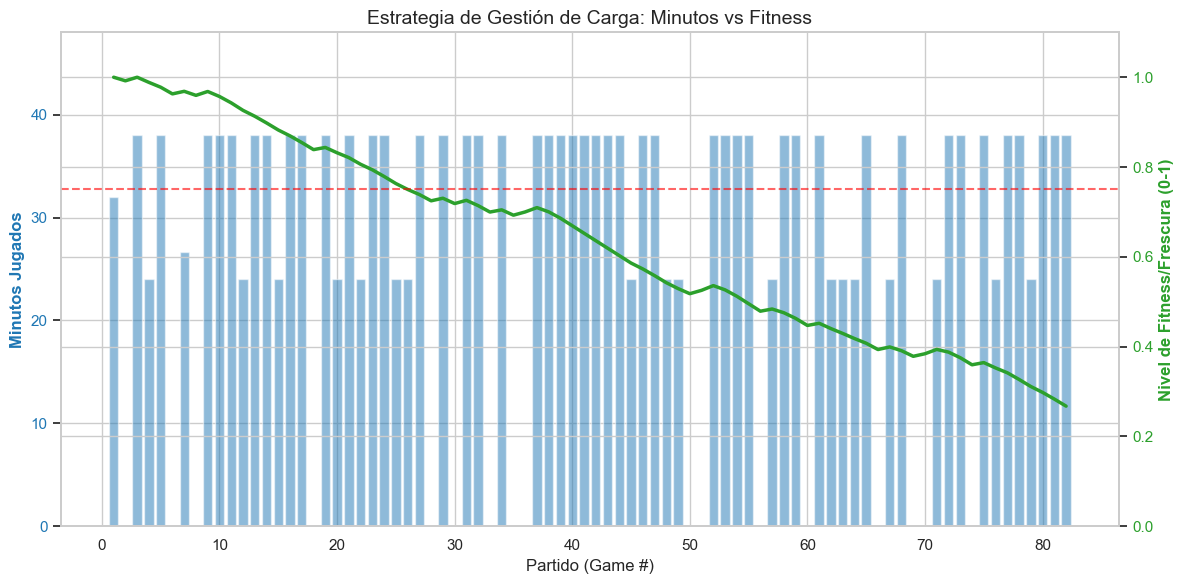

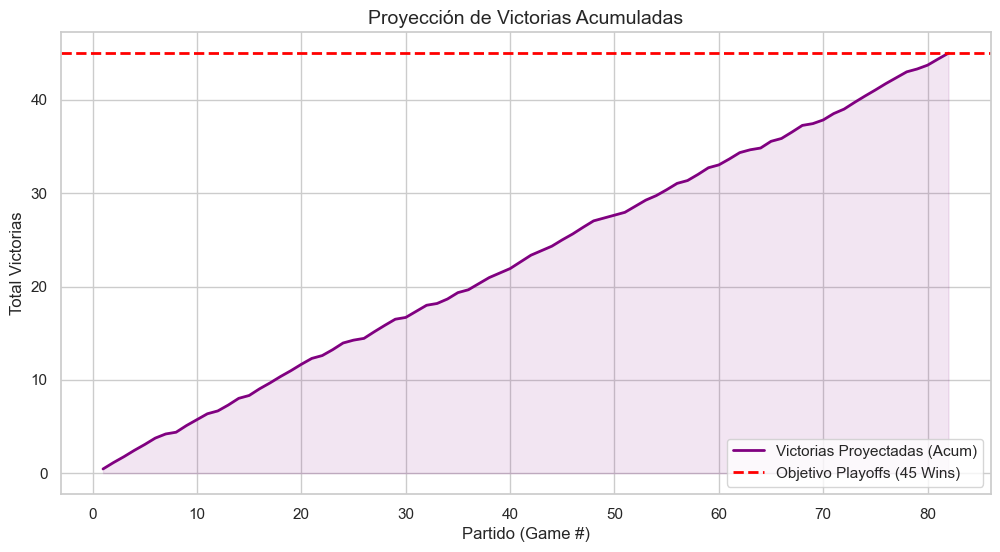

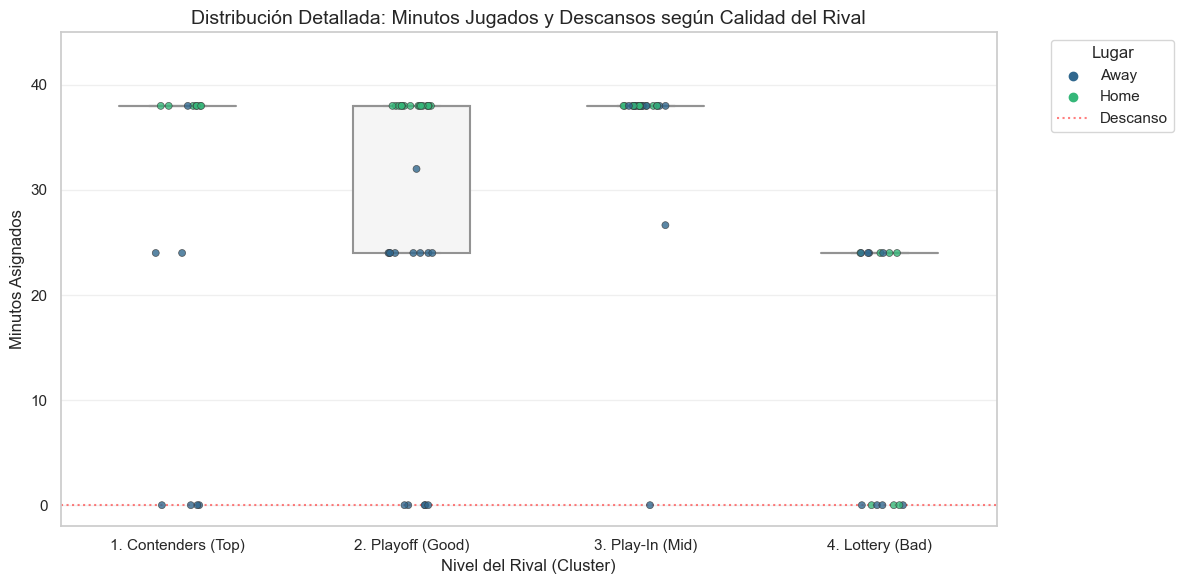

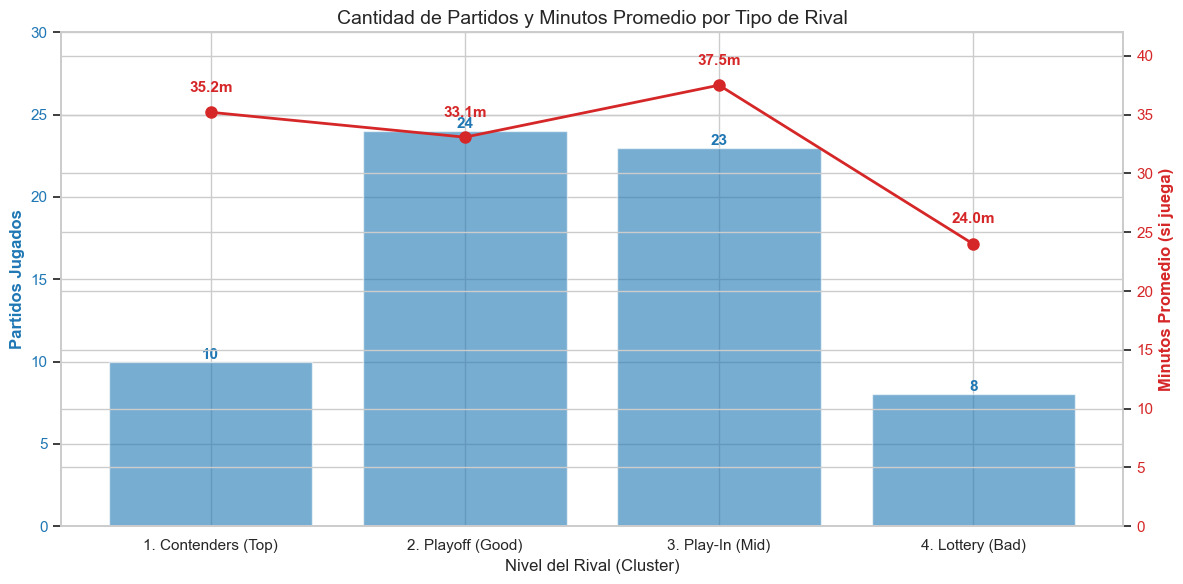

In [318]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# --- GRAFICO 1: Evolución de Minutos y Fitness ---
fig, ax1 = plt.subplots()

# Eje Izquierdo: Minutos (Barras)
color_min = 'tab:blue'
ax1.set_xlabel('Partido (Game #)')
ax1.set_ylabel('Minutos Jugados', color=color_min, fontweight='bold')
ax1.bar(df_games_detailed["G"], df_games_detailed["Minutos (X)"], color=color_min, alpha=0.5, label='Minutos')
ax1.tick_params(axis='y', labelcolor=color_min)
ax1.set_ylim(0, 48) # Límite físico de un partido NBA

# Eje Derecho: Fitness (Línea)
ax2 = ax1.twinx()  
color_fit = 'tab:green'
ax2.set_ylabel('Nivel de Fitness/Frescura (0-1)', color=color_fit, fontweight='bold')
ax2.plot(df_games_detailed["G"], df_games_detailed["Fitness (F)"], color=color_fit, linewidth=2.5, label='Fitness Trend')
ax2.tick_params(axis='y', labelcolor=color_fit)
ax2.set_ylim(0, 1.1)

# Línea de Objetivo de Fitness
ax2.axhline(0.75, color='red', linestyle='--', alpha=0.6, label='Objetivo Fitness (0.75)')

plt.title('Estrategia de Gestión de Carga: Minutos vs Fitness', fontsize=14)
fig.tight_layout()
plt.show()

# --- GRAFICO 2: Victorias Acumuladas ---
# Calcular acumulado
df_games_detailed["Wins_Cum"] = df_games_detailed["Win % Est"].cumsum()

plt.figure()
plt.plot(df_games_detailed["G"], df_games_detailed["Wins_Cum"], color='purple', linewidth=2, label='Victorias Proyectadas (Acum)')
plt.axhline(45, color='red', linestyle='--', linewidth=2, label='Objetivo Playoffs (45 Wins)')

# Relleno
plt.fill_between(df_games_detailed["G"], df_games_detailed["Wins_Cum"], color='purple', alpha=0.1)

plt.xlabel('Partido (Game #)')
plt.ylabel('Total Victorias')
plt.title('Proyección de Victorias Acumuladas', fontsize=14)
plt.legend()
plt.show()

# --- GRAFICO 3: Minutos por Cluster de Oponente (Detallado) ---
# Separamos datos: Boxplot para intensidad de juego (SI) vs Stripplot para TODAS las decisiones (SI + NO)
df_played_only = df_games_detailed[df_games_detailed["Juega (Y)"] == "SI"]

# Definir orden explícito de los clusters (Mejor -> Peor)
cluster_order = ["1. Contenders (Top)", "2. Playoff (Good)", "3. Play-In (Mid)", "4. Lottery (Bad)"]

plt.figure()

# 1. Boxplot de fondo: Solo jugados (para no "aplastar" la caja con los ceros)
sns.boxplot(
    x="Cluster Name", 
    y="Minutos (X)", 
    data=df_played_only,
    order=cluster_order, 
    showfliers=False, 
    color="whitesmoke",
    width=0.5
)

# 2. Stripplot: TODOS los partidos (incluidos los 0 minutos/descansos)
sns.stripplot(
    x="Cluster Name", 
    y="Minutos (X)", 
    data=df_games_detailed,
    order=cluster_order,
    hue="Place",      # Diferenciamos Casa vs Fuera
    palette="viridis", 
    size=5, 
    jitter=True,      # Dispersión
    alpha=0.8,
    linewidth=0.5,
    edgecolor="gray"
)

# Línea de referencia y márgenes para ver bien los descansos
plt.axhline(0, color='red', linestyle=':', alpha=0.5, label='Descanso')
plt.ylim(-2, 45) # Margen inferior para ver los puntos en 0

plt.title('Distribución Detallada: Minutos Jugados y Descansos según Calidad del Rival', fontsize=14)
plt.xlabel('Nivel del Rival (Cluster)', fontsize=12)
plt.ylabel('Minutos Asignados', fontsize=12)
plt.legend(title='Lugar', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- GRAFICO 4: Resumen de Partidos y Minutos por Cluster ---
# Agregamos datos: Contar partidos jugados y promedio de minutos
summary_data = df_games_detailed[df_games_detailed["Juega (Y)"] == "SI"].groupby("Cluster Name").agg(
    Games_Played=('G', 'count'),
    Avg_Minutes=('Minutos (X)', 'mean')
).reindex(cluster_order).fillna(0)

fig, ax1 = plt.subplots()

# Eje 1 (Barras): Cantidad de Partidos
color_bar = 'tab:blue'
ax1.set_xlabel('Nivel del Rival (Cluster)', fontsize=12)
ax1.set_ylabel('Partidos Jugados', color=color_bar, fontweight='bold', fontsize=12)
bars = ax1.bar(summary_data.index, summary_data['Games_Played'], color=color_bar, alpha=0.6, label='Partidos Jugados')
ax1.tick_params(axis='y', labelcolor=color_bar)
# Ajustar limite Y para dar espacio arriba
ax1.set_ylim(0, max(summary_data['Games_Played']) * 1.25) 

# Anotar valores en barras
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', color=color_bar, fontweight='bold', fontsize=11)

# Eje 2 (Línea/Punto): Minutos Promedio
ax2 = ax1.twinx()
color_line = 'tab:red'
ax2.set_ylabel('Minutos Promedio (si juega)', color=color_line, fontweight='bold', fontsize=12)
ax2.plot(summary_data.index, summary_data['Avg_Minutes'], color=color_line, marker='o', linewidth=2, markersize=8, label='Minutos Promedio')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 42) # Escala de minutos (hasta 42 para dar aire)

# Anotar valores en línea
for i, txt in enumerate(summary_data['Avg_Minutes']):
    if txt > 0:
        ax2.text(i, txt + 1.5, f'{txt:.1f}m', ha='center', va='bottom', color=color_line, fontweight='bold', fontsize=11)

plt.title('Cantidad de Partidos y Minutos Promedio por Tipo de Rival', fontsize=14)
fig.tight_layout()
plt.show()